# Data Cleaning in Practice

## Imports

In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import gcleaner

importlib.reload(gcleaner)

import gcleaner as gcln

## Overview

In [3]:
df = pd.read_csv("./dataset/dirty_cafe_sales.csv", na_values=["UNKNOWN", "ERROR"])

print("-"*32, "[ Shape ]")
print(f"Shape = {df.shape}")

print("-"*32, "[ The first five ]")
display(df.head())

print("-"*32, "[ General information ]")
print(df.info())

print("-"*32, "[ Some properties ]")
display(df.describe())

-------------------------------- [ Shape ]
Shape = (10000, 8)
-------------------------------- [ The first five ]


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


-------------------------------- [ General information ]
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  str    
 1   Item              9031 non-null   str    
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    6822 non-null   str    
 6   Location          6039 non-null   str    
 7   Transaction Date  9540 non-null   str    
dtypes: float64(3), str(5)
memory usage: 625.1 KB
None
-------------------------------- [ Some properties ]


,Quantity,Price Per Unit,Total Spent
count,9521.000000,9467.000000,9498.000000
mean,3.028463,2.949984,8.924352
std,1.419007,1.278450,6.009919
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,8.000000
75%,4.000000,4.000000,12.000000
max,5.000000,5.000000,25.000000


## NaN Values

In [4]:
nan_counts = df.isna().sum()
display(nan_counts)

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [5]:
rows_with_null = df[df.isna().any(axis=1)]
display(rows_with_null)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3.0,3.0,9.0,NaN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,NaN,2023-10-28
...,...,...,...,...,...,...,...,...
9994,TXN_7851634,NaN,4.0,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02


## Data Type Conversion

In [6]:
df["Quantity"] = df["Quantity"].astype("float")
df["Price Per Unit"] = df["Price Per Unit"].astype("float")
df["Total Spent"] = df["Total Spent"].astype("float")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], format="%Y-%m-%d", errors="coerce")

## Checking for out-of-scope (improper) values

In [7]:
col_item = df["Item"]
col_quantity = df["Quantity"]
col_price = df["Price Per Unit"]
col_total = df["Total Spent"]
col_payment = df["Payment Method"]
col_location = df["Location"]
col_date = df["Transaction Date"]

---

### Item

Checking if there exists a value that is out of the predetermined items.

In [8]:
col_item.unique()

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',        nan,
 'Sandwich',    'Juice',      'Tea']
Length: 9, dtype: str

> ✅ No item that isn't predetermined.

---

### Quantity

Checking if there exists a negative or a decimal quantity.

In [9]:
print("Quantities that are zero or negative:", col_quantity.le(0).sum())

Quantities that are zero or negative: 0


In [10]:
decimal_quantities = (col_quantity.notna() & (col_quantity % 1 != 0)).sum()

print("Quantities that are decimal:", decimal_quantities)

Quantities that are decimal: 0


> ✅ No negative or decimal quantities.

---

### Price Per Unit & Total Spent

Checking if there exists a non-positive unit price / total spent.

In [11]:
print("Unit prices that are non-positive:", col_price.le(0).sum())
print("Total spent that are non-positive:", col_total.le(0).sum())

Unit prices that are non-positive: 0
Total spent that are non-positive: 0


Checking that unit prices are srtictly within the predetermined values: 1, 1.5, 2, 3, 4, or 5.

In [12]:
col_price.unique()

array([2. , 3. , 1. , 5. , 4. , 1.5, nan])

> ✅ No zero or negative prices / total spent.

---

There's no need to explicitly check for hidden whitespaces or do `strip()` because in our case the `unique()` method we've used seems to handle everything perfectly.

### Payment Method & Location & Transaction Date

Checking if there exists any improper value for payment method / location / transaction date.

In [13]:
print(col_payment.unique())
print(col_location.unique())
print(col_date.unique())

<StringArray>
['Credit Card', 'Cash', nan, 'Digital Wallet']
Length: 4, dtype: str
<StringArray>
['Takeaway', 'In-store', nan]
Length: 3, dtype: str
<DatetimeArray>
['2023-09-08 00:00:00', '2023-05-16 00:00:00', '2023-07-19 00:00:00',
 '2023-04-27 00:00:00', '2023-06-11 00:00:00', '2023-03-31 00:00:00',
 '2023-10-06 00:00:00', '2023-10-28 00:00:00', '2023-07-28 00:00:00',
 '2023-12-31 00:00:00',
 ...
 '2023-08-01 00:00:00', '2023-01-20 00:00:00', '2023-11-11 00:00:00',
 '2023-02-13 00:00:00', '2023-07-30 00:00:00', '2023-02-17 00:00:00',
 '2023-05-20 00:00:00', '2023-11-05 00:00:00', '2023-03-27 00:00:00',
 '2023-07-03 00:00:00']
Length: 366, dtype: datetime64[us]


> ✅ Everything is fine.

## Inter-column Deduction

### Relation between Item and Price Per Unit (1st round check)

In [14]:
df.isna().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [15]:
item_price_map = {
    "Cookie": 1,
    "Tea": 1.5,
    "Coffee": 2,
    "Cake": 3,
    "Juice": 3,
    "Sandwich": 4,
    "Smoothie": 4,
    "Salad": 5,
}

price_item_map = {
    1: "Cookie",
    1.5: "Tea",
    2: "Coffee",
    3: float("nan"),
    4: float("nan"),
    5: "Salad",
    # excluded Cake-Juice-3 and Sandwich-Smoothie-4
}

In [16]:
vib_ip = gcln.get_valid_invalid(df[["Item", "Price Per Unit"]])

In [17]:
# Assigning missing price values based on the item
valid_item_invalid_price = vib_ip["valid_item"] & vib_ip["invalid_price_per_unit"]
if valid_item_invalid_price.sum() > 0:
    df.loc[valid_item_invalid_price, "Price Per Unit"] = df.loc[valid_item_invalid_price, "Item"].map(lambda x: item_price_map[x])

# Assigning missing item values based on the price
invalid_item_valid_price = vib_ip["invalid_item"] & vib_ip["valid_price_per_unit"]
if invalid_item_valid_price.sum() > 0:
    df.loc[invalid_item_valid_price, "Item"] = df.loc[invalid_item_valid_price, "Price Per Unit"].map(lambda x: price_item_map[x])

In [18]:
df.isna().sum()

Transaction ID         0
Item                 501
Quantity             479
Price Per Unit        54
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

This Item-Price assignment reduces the NaN values of:
- `Item` from 969 to 501
- `Price Per Unit` from 533 to 54.

### Relation among Quantity, Price Per Unit, and Total Spent

`Total Spent` is the product of `Quantity` and `Price Per Unit`.

So, let's check if there exists a case where `Total Spent` is null while the `Quantity` and `Price Per Unit` have valid values. Why do this? We can deduce the valid for total spent by taking the product of quantity and price per unit.

Do this while targeting the two columns too because in doing so, if there exist such cases, we can deduce for example the value for `Quantity` from the rest columns.

---

#### Deducing Total Spent

In [19]:
na_count_init_total = df["Total Spent"].isna().sum()
print(f"Initial NaN count of Total Spent column: {na_count_init_total}")

Initial NaN count of Total Spent column: 502


In [20]:
vib_qpt = gcln.get_valid_invalid(df[["Quantity", "Price Per Unit", "Total Spent"]])
# vib stands for Valid Invalid Book

In [21]:
mask_invalid_total = vib_qpt["valid_quantity"] & vib_qpt["valid_price_per_unit"] & vib_qpt["invalid_total_spent"]
df.loc[mask_invalid_total, "Total Spent"] = (
    df.loc[mask_invalid_total, "Quantity"] * 
    df.loc[mask_invalid_total, "Price Per Unit"]
    )

In [22]:
na_count_after_total = df["Total Spent"].isna().sum()
print(f"After deduction NaN count of Total Spent column: {na_count_after_total}")

After deduction NaN count of Total Spent column: 23


- Initial NaN count = 502
- After deduction NaN count = 23

A total of 479 NaN values are deduced to their valid values for `Total Spent`

---

#### Deducing Quantity

In [23]:
na_count_init_quantity = df["Quantity"].isna().sum()
print(f"Initial NaN count of Quantity column: {na_count_init_quantity}")

Initial NaN count of Quantity column: 479


In [24]:
vib_qpt = gcln.get_valid_invalid(df[["Quantity", "Price Per Unit", "Total Spent"]])

In [25]:
mask_invalid_quantity = vib_qpt["invalid_quantity"] & vib_qpt["valid_price_per_unit"] & vib_qpt["valid_total_spent"]
df.loc[mask_invalid_quantity, "Quantity"] = (
    df[mask_invalid_quantity]["Total Spent"] /
    df[mask_invalid_quantity]["Price Per Unit"]
    )

In [26]:
na_count_after_quantity = df["Quantity"].isna().sum()
print(f"After deduction NaN count of Quantity column: {na_count_after_quantity}")

After deduction NaN count of Quantity column: 23


- Initial NaN count = 479
- After deduction NaN count = 23

A total of 456 NaN values are deduced to their valid values for `Quantity`

---

#### Deducing Price Per Unit

In [27]:
na_count_init_price = df["Price Per Unit"].isna().sum()
print(f"Initial NaN count of Price Per Unit column: {na_count_init_price}")

Initial NaN count of Price Per Unit column: 54


In [28]:
vib_qpt = gcln.get_valid_invalid(df[["Quantity", "Price Per Unit", "Total Spent"]])

In [29]:
mask_invalid_price = vib_qpt["valid_quantity"] & vib_qpt["invalid_price_per_unit"] & vib_qpt["valid_total_spent"]
df.loc[mask_invalid_price, "Price Per Unit"] = (
    df[mask_invalid_price]["Total Spent"] /
    df[mask_invalid_price]["Quantity"]
    )

In [30]:
na_count_after_price = df["Price Per Unit"].isna().sum()
print(f"After deduction NaN count of Price Per Unit column: {na_count_after_price}")

After deduction NaN count of Price Per Unit column: 6


- Initial NaN count = 54
- After deduction NaN count = 6

A total of 48 NaN values are deduced to their valid values for `Price Per Unit`

---

In [31]:
df.isna().sum()

Transaction ID         0
Item                 501
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

### Relation between Item and Price Per Unit (2nd round check)

In [32]:
vib_ip = gcln.get_valid_invalid(df[["Item", "Price Per Unit"]])

In [33]:
# Assigning missing item values based on the price
invalid_item_valid_price = vib_ip["invalid_item"] & vib_ip["valid_price_per_unit"]
if invalid_item_valid_price.sum() > 0:
    df.loc[invalid_item_valid_price, "Item"] = df.loc[invalid_item_valid_price, "Price Per Unit"].map(lambda x: price_item_map[x])

In [34]:
df.isna().sum()

Transaction ID         0
Item                 480
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

With this second round check, I have managed to deduce **21 more values (501 - 480) for missing items**. This is possible because we got more valid price values in the quantity-price-total deduction step.

## Checking for proper relations among columns

Things to look for:

- ensure for every item, its corresponding unit price is the same with the predetermined value.
- ensure every total spent is the product of quantity and unit price.

### Checking item-price mismatch

In [35]:
for i in range(len(df)):
    item_value = df["Item"][i]
    price_value = df["Price Per Unit"][i]

    if pd.isna(item_value) or pd.isna(price_value):
        continue
    
    if item_price_map[item_value] != price_value:
        print(f"item-price mismatch found at [{i}]:", df.iloc[i])
else:
    print("Loop completed")

Loop completed


> ✅ Everything is fine.

### Checking quantity-price-total mismatch

In [36]:
for i in range(len(df)):
    quantity_value = df["Quantity"][i]
    price_value = df["Price Per Unit"][i]
    total_value = df["Total Spent"][i]

    if pd.isna(quantity_value) or pd.isna(price_value) or pd.isna(total_value):
        continue

    if total_value != quantity_value * price_value:
        print(f"quantity-price-total mismatch found at [{i}]:", df.iloc[i])
else:
    print("Loop completed")

Loop completed


> ✅ Everything is fine.

In [37]:
df.isna().sum()

Transaction ID         0
Item                 480
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

## Imputation / Best Guess

In [87]:
df["Transaction Month"] = df["Transaction Date"].dt.to_period("M").dt.strftime("%b")

### `Location` vs `Total Spent`

In [66]:
df[["Total Spent", "Location"]].dropna().groupby("Location").describe()

Total Spent                                               
               count      mean       std  min  25%  50%   75%   max
Location                                                           
In-store      3008.0  9.033910  6.047769  1.0  4.0  8.0  12.0  25.0
Takeaway      3016.0  8.803879  5.970804  1.0  4.0  7.5  12.0  25.0

### `Payment Method` vs `Total Spent`

In [65]:
df[["Payment Method", "Total Spent"]].dropna().groupby("Payment Method").describe()

Total Spent                                               
                     count      mean       std  min  25%  50%   75%   max
Payment Method                                                           
Cash                2254.0  9.051686  6.081822  1.0  4.0  8.0  12.0  25.0
Credit Card         2269.0  9.019833  6.025431  1.0  4.0  8.0  12.0  25.0
Digital Wallet      2285.0  8.933917  6.012666  1.0  4.0  8.0  12.0  25.0

### `Location` vs `Item`

In [67]:
table_item_location_size = df[["Item", "Location"]].dropna().pivot_table(
    index="Item",
    columns="Location",
    aggfunc="size"
)

# table_item_location_size["In-store Percentage"] = ((table_item_location_size["In-store"] / (table_item_location_size["In-store"] + table_item_location_size["Takeaway"])) * 100).round(1)
# table_item_location_size["Takeaway Percentage"] = ((table_item_location_size["Takeaway"] / (table_item_location_size["In-store"] + table_item_location_size["Takeaway"])) * 100).round(1)

display(table_item_location_size)

Location,In-store,Takeaway
Item,,
Cake,321,343
Coffee,352,396
Cookie,373,402
Juice,361,341
Salad,406,378
Sandwich,370,345
Smoothie,322,304
Tea,369,368


### `Item` vs `Quantity`

In [70]:
df[["Item", "Quantity"]].dropna().groupby("Item").median()

,Quantity
Item,
Cake,3.0
Coffee,3.0
Cookie,3.0
Juice,3.0
Salad,3.0
Sandwich,3.0
Smoothie,3.0
Tea,3.0


### `Item` vs `Transaction Month`

In [103]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df_sub_item = df[df["Item"].isin(["Cake", "Juice", "Sandwich", "Smoothie"])]

table_item_month_size = (
    df_sub_item[["Item", "Transaction Month"]][df_sub_item["Item"].isin(["Cake", "Juice"])]
    .dropna()
    .pivot_table(index="Item", columns="Transaction Month", aggfunc="size")
    .reindex(columns=month_order, fill_value=0)
)

display(table_item_month_size)

Transaction Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Item,,,,,,,,,,,,
Cake,95,75,101,87,85,84,85,87,101,100,97,85
Juice,100,94,105,96,96,94,75,78,87,100,93,106


### Impute `Item`

We know that the missing items are within Cake, Juice, Sandwich and Smoothie (except for the places where Price Per Unit is undefined). This is due to the inter-column deduction between item and unit prices, and that cake and juice have the same unit prices as well as sandwich and smoothie which makes it impossible to deduce these items.

In this section, we'll see if there is any hidden patter or trend that can enable us to put our best guesses for the missing values.

#### Cake VS Juice AND Sandwich VS Smoothie

------------------------------------------------ Cake vs Juice


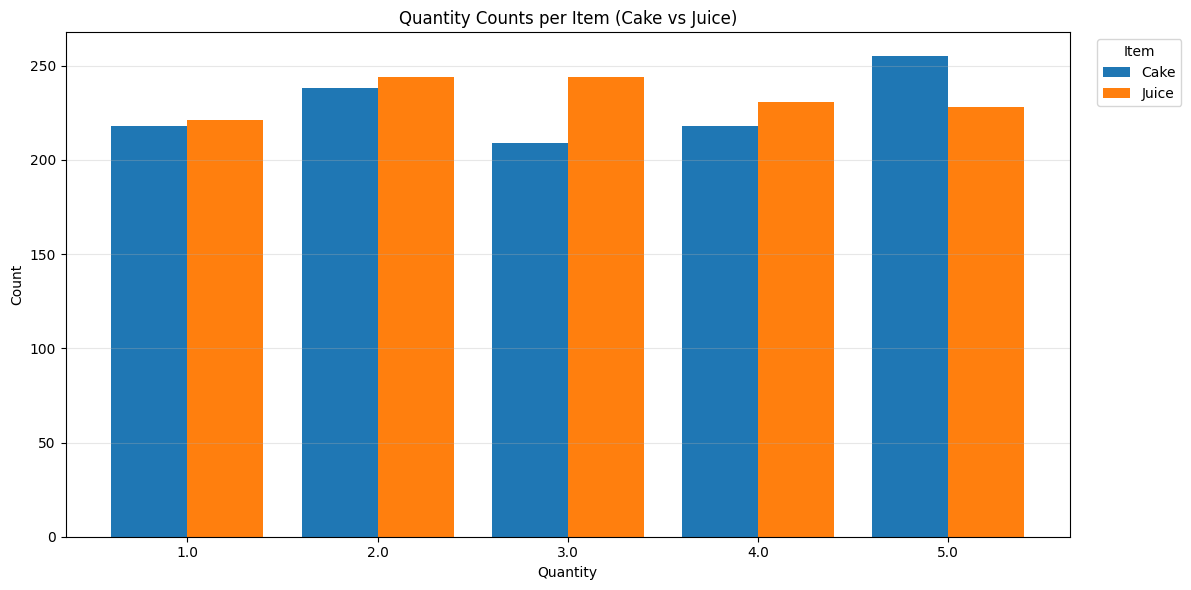

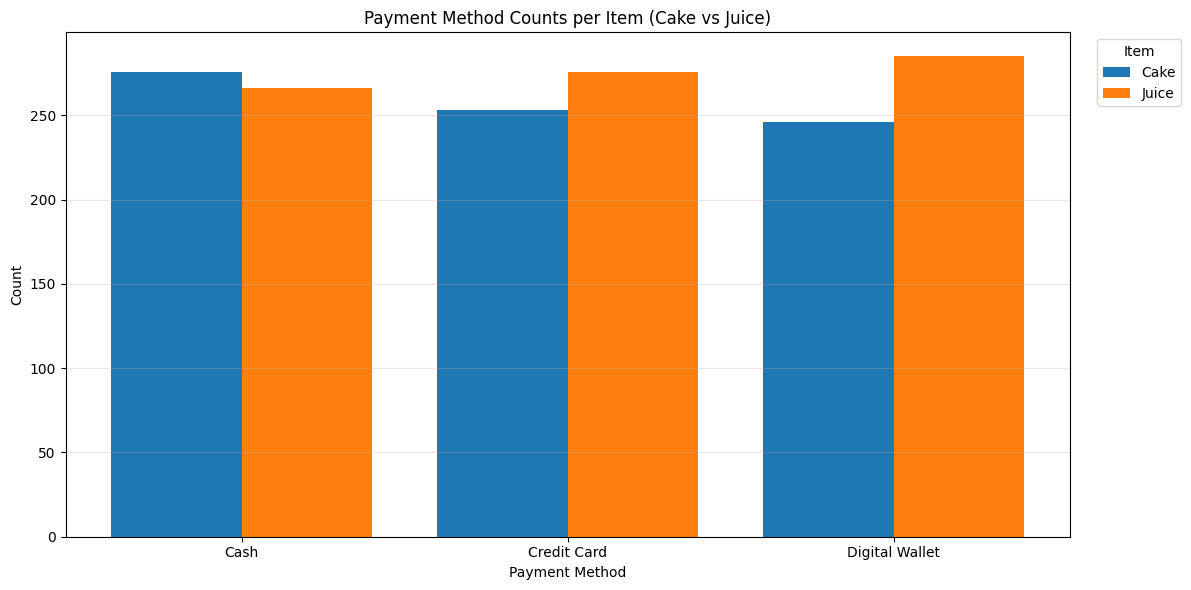

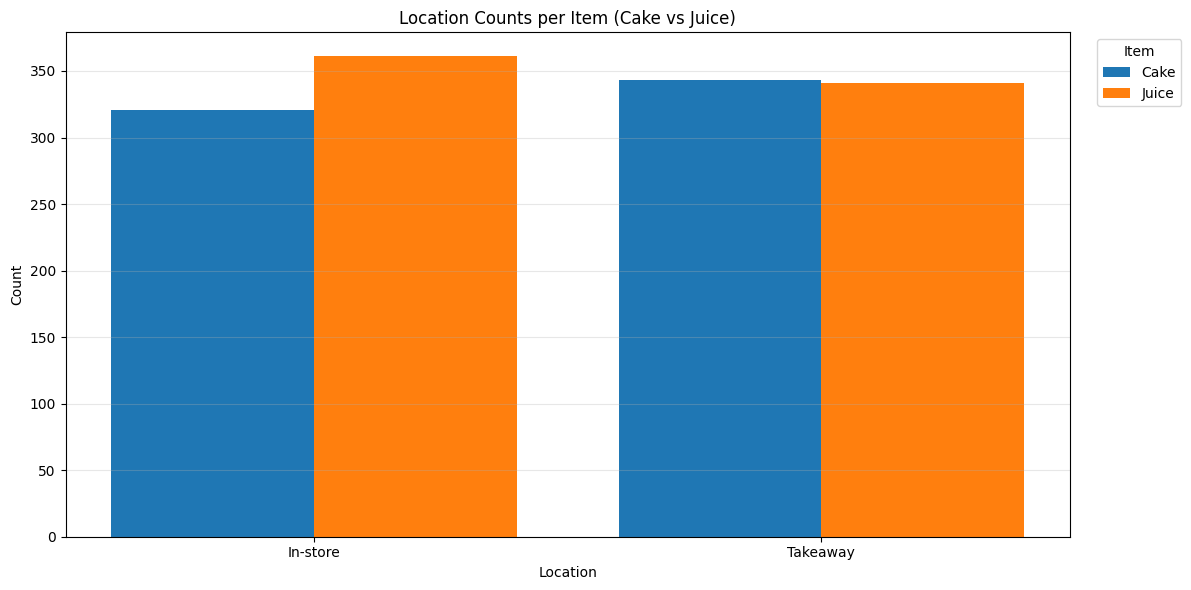

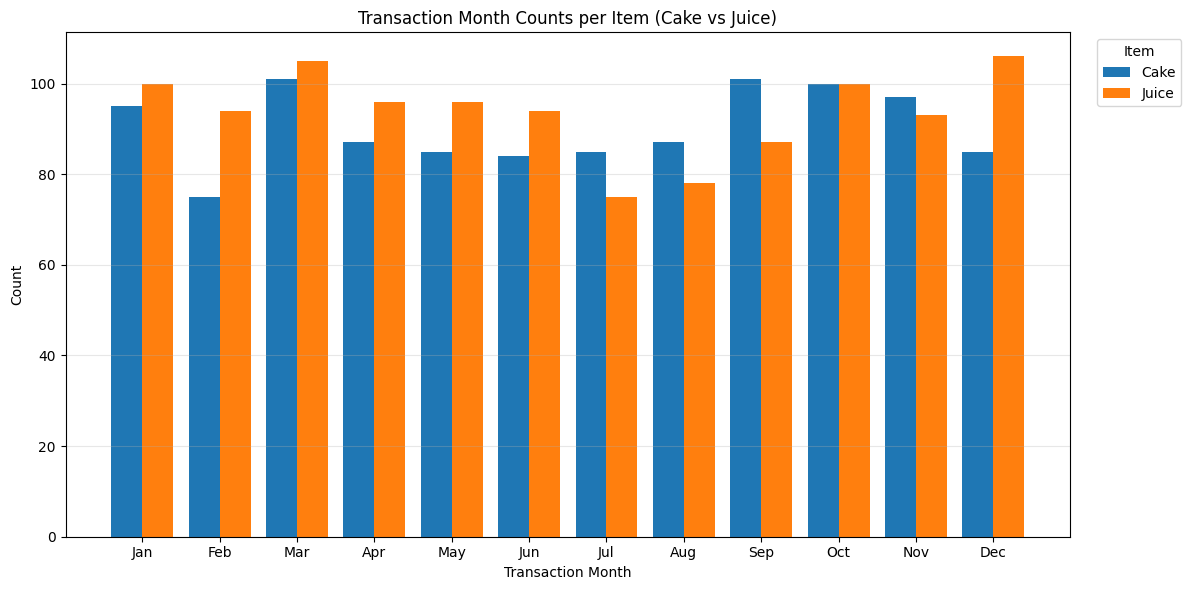


------------------------------------------------ Sandwich vs Smoothie


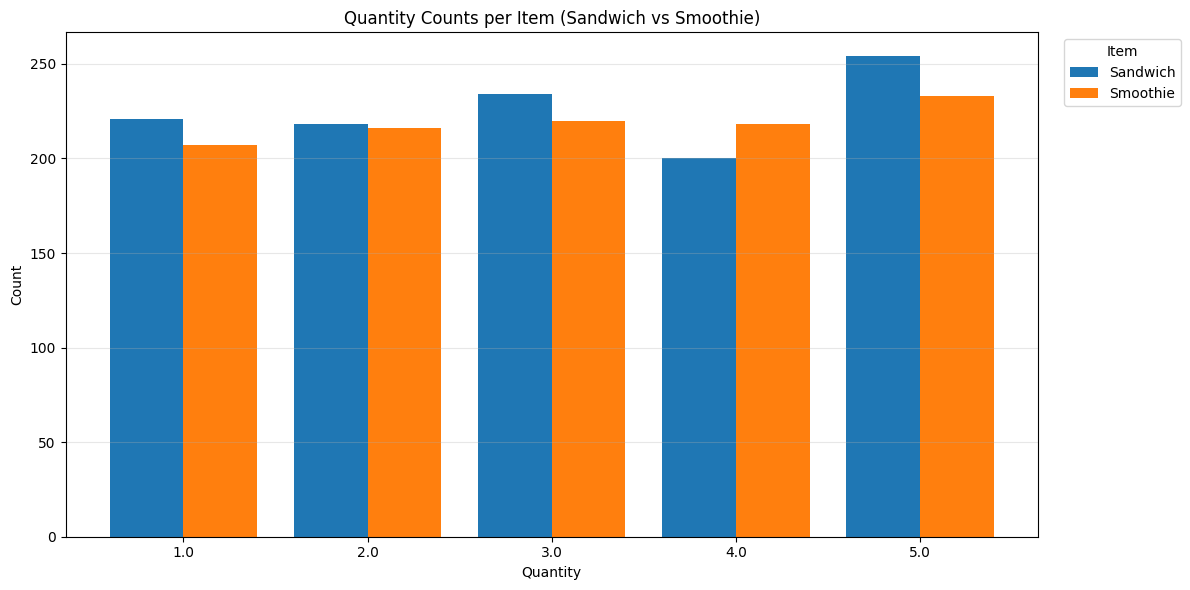

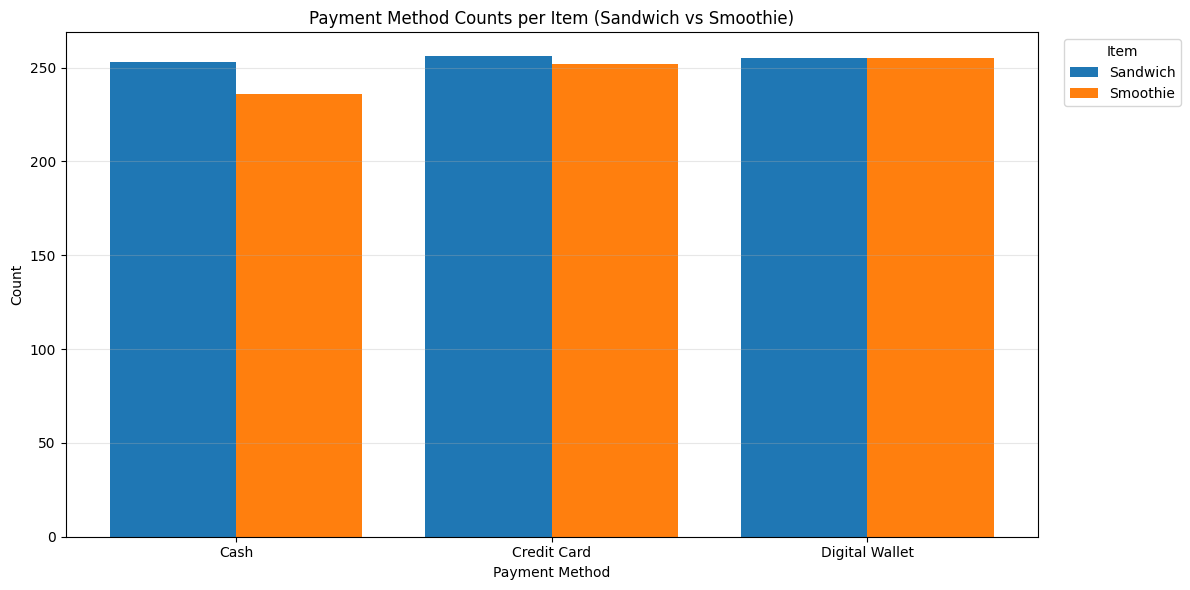

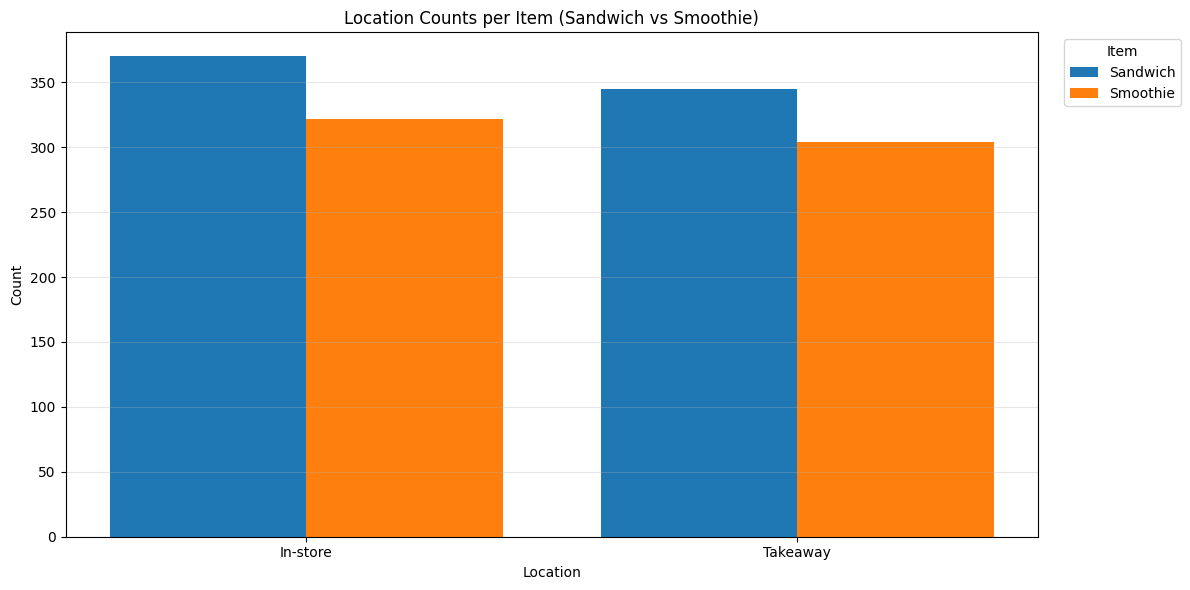

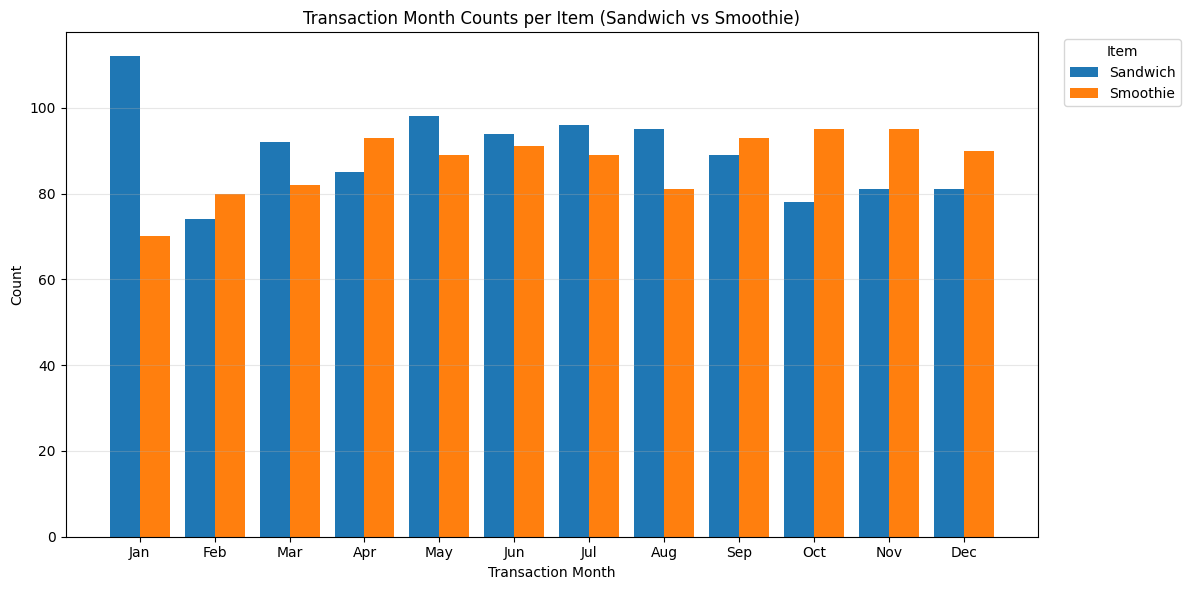

In [139]:
df_price = df[df["Price Per Unit"].notna()]

target_pairs = [("Cake", "Juice"), ("Sandwich", "Smoothie")]

for target_pair in target_pairs:
    print("-"*48, f"{target_pair[0]} vs {target_pair[1]}")

    sub_df = df_price[df_price["Item"].isin(target_pair)]

    cols = ["Quantity", "Payment Method", "Location", "Transaction Month"]

    for col in cols:
        table = (
            sub_df[["Item", col]]
            .dropna()
            .pivot_table(
                index="Item",
                columns=col,
                aggfunc="size"
            )
        )
        
        if col == "Transaction Month":
            month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
            table = table.reindex(columns=month_order, fill_value=0)

        fig, ax = plt.subplots(figsize=(12, 6))

        x = np.arange(len(table.columns))
        items = table.index
        width = 0.8 / len(items)

        for idx, item in enumerate(items):
            ax.bar(x + idx * width, table.loc[item].values, width=width, label=item)

        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.set_title(f"{col} Counts per Item ({target_pair[0]} vs {target_pair[1]})")
        ax.set_xticks(x + width * (len(items) - 1) / 2)
        ax.set_xticklabels(table.columns)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="Item", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    print("")


The only significant clue I can see from all these plots is in the amount of size difference between Sandwich and Smoothie sales in the month January; Sandwich sales account for around 62% of the sales with a unit price of 4 during that month. Should we fill the missing items of a unit price 4 with Sandwich?

In [149]:
df_valid_sandwich_smoothie = df_price[df_price["Item"].isin(["Sandwich", "Smoothie"])]
df_missing_sandwich_smoothie = df_price[df_price["Item"].isna() & (df_price["Price Per Unit"] == 4)]

In [150]:
display(df_valid_sandwich_smoothie)
display(df_missing_sandwich_smoothie)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Transaction Month
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31,Mar
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,NaN,2023-10-28,Oct
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31,Dec
11,TXN_3051279,Sandwich,2.0,4.0,8.0,Credit Card,Takeaway,NaT,NaN
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03,May
...,...,...,...,...,...,...,...,...,...
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-store,2023-12-14,Dec
9991,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24,Feb
9992,TXN_2739140,Smoothie,4.0,4.0,16.0,NaN,In-store,2023-07-05,Jul
9993,TXN_4766549,Smoothie,2.0,4.0,8.0,Cash,NaN,2023-10-20,Oct


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Transaction Month
151,TXN_4031509,NaN,4.0,4.0,16.0,Credit Card,Takeaway,2023-01-04,Jan
165,TXN_3226832,NaN,5.0,4.0,20.0,Cash,NaN,2023-09-04,Sep
168,TXN_3494565,NaN,2.0,4.0,8.0,NaN,NaN,2023-07-10,Jul
184,TXN_3831848,NaN,1.0,4.0,4.0,Digital Wallet,Takeaway,2023-11-03,Nov
216,TXN_3499124,NaN,4.0,4.0,16.0,Credit Card,NaN,2023-08-25,Aug
...,...,...,...,...,...,...,...,...,...
9885,TXN_4659954,NaN,3.0,4.0,12.0,Credit Card,In-store,NaT,NaN
9918,TXN_2292088,NaN,1.0,4.0,4.0,Digital Wallet,Takeaway,2023-03-04,Mar
9946,TXN_8807600,NaN,1.0,4.0,4.0,Cash,Takeaway,2023-09-24,Sep
9981,TXN_4583012,NaN,5.0,4.0,20.0,Digital Wallet,NaN,2023-02-27,Feb


In [155]:
df_missing_sandwich_smoothie_valid_month = df_missing_sandwich_smoothie[df_missing_sandwich_smoothie["Transaction Month"].notna()]

df_missing_sandwich_smoothie_valid_month.groupby("Transaction Month").size()

Transaction Month
Apr    16
Aug    21
Dec    31
Feb    22
Jan    14
Jul    12
Jun    22
Mar    14
May    20
Nov    13
Oct    11
Sep    20
dtype: int64

In applying the aforementioned way, we will fill 14 values which is not that much.

The conclusion is that we are unable to deduce the value for the missing items. We shouldn't fill them with a general term like "Unspecified" too because the essence of the dataset is about the sales of items made on each day throught the year; having every detail but not the item won't make any sense. So, we should drop all rows with undefinied items.

In [156]:
df["Item"].isna().sum()

np.int64(480)

In [158]:
df.dropna(subset=["Item"], inplace=True)

In [159]:
df.isna().sum()

Transaction ID          0
Item                    0
Quantity               20
Price Per Unit          0
Total Spent            20
Payment Method       3031
Location             3769
Transaction Date      436
Transaction Month     436
dtype: int64

### Impute `Location`